In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"parralex","key":"0c383bd852eb531b27efea09f239a555"}'}

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:14<00:00, 18.4MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

**Data Preparation**

In [ ]:
train_dir = 'data/chest_xray/train'
val_dir = 'data/chest_xray/val'
test_dir = 'data/chest_xray/test'
batch_size = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


**CNN Model Build**

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    epochs=50,
    validation_data=val_data
)

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.8031 - loss: 0.4365 - val_accuracy: 0.8750 - val_loss: 0.4500
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8696 - loss: 0.3056 - val_accuracy: 0.6250 - val_loss: 0.8171
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8969 - loss: 0.2556 - val_accuracy: 0.8750 - val_loss: 0.5092
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.9072 - loss: 0.2306 - val_accuracy: 0.7500 - val_loss: 0.7551
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9153 - loss: 0.2080 - val_accuracy: 0.6250 - val_loss: 1.0023
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9235 - loss: 0.2067 - val_accuracy: 0.6250 - val_loss: 1.2279
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9195 - loss: 0.1951 - val_accuracy: 0.8125 - val_loss: 0.4636
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9204 - loss: 0.2011 - val_accuracy: 0.7500 - v

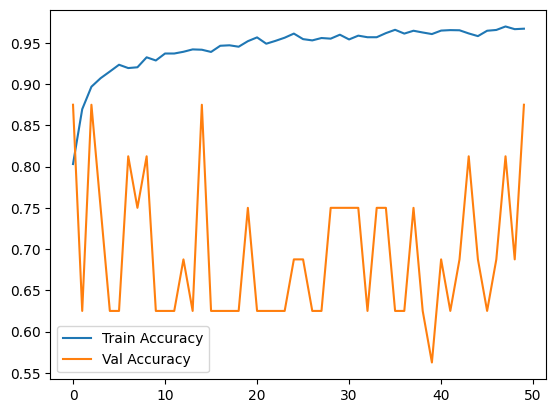

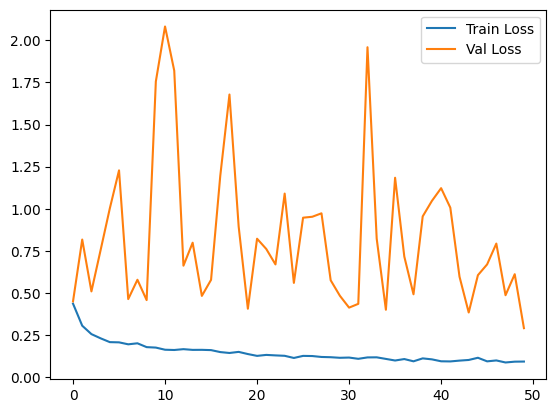

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.show()

plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 552ms/step - accuracy: 0.9183 - loss: 0.2893
Test Accuracy: 0.9182692170143127


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 426ms/step


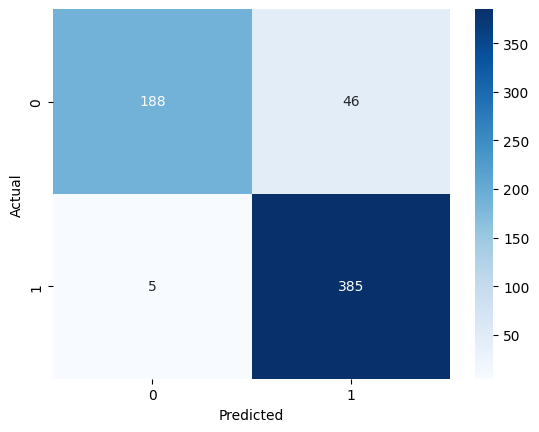

In [ ]:
predictions = model.predict(test_data)
predicted_classes = (predictions > 0.5).astype("int32")

true_classes = test_data.classes

cm = confusion_matrix(true_classes, predicted_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print(classification_report(true_classes, predicted_classes, target_names=['Normal', 'Pneumonia']))

              precision    recall  f1-score   support

      Normal       0.97      0.80      0.88       234
   Pneumonia       0.89      0.99      0.94       390

    accuracy                           0.92       624
   macro avg       0.93      0.90      0.91       624
weighted avg       0.92      0.92      0.92       624

